# Exercise 04: Hyperparameter Selection (AIC, BIC, OOS RMSE)

**CBIOMES Workshop · Time Series in R**

In this notebook, you will:

1. Compare three lag-order selection strategies on a **simulated AR(2) process**:
   - **AIC** (Akaike Information Criterion): penalises complexity lightly.
   - **BIC** (Bayesian Information Criterion): penalises complexity more strongly.
   - **Out-of-sample RMSE**: direct measure of predictive accuracy.
2. See where these criteria agree and where they don't.
3. Internalise the difference between *model selection for explanation* and *model selection for forecasting*.

## Setup

All packages already installed in the Docker container.

## Background — three criteria

| Criterion | Formula (loosely) | Behaviour |
|---|---|---|
| **AIC** | $-2\log L + 2k$ | favours fit, mild complexity penalty |
| **BIC** | $-2\log L + k \log n$ | stronger penalty as $n$ grows; tends to pick smaller models |
| **OOS RMSE** | error on data the model has never seen | what really matters for forecasting |

For a Gaussian AR with residual sum of squares $RSS$ and $n$ residuals:
$$ \text{AIC} = n\,\log(RSS/n) + 2k, \qquad \text{BIC} = n\,\log(RSS/n) + k\,\log(n). $$

---

## Part 1: Simulate a stationary AR(2)

Run the following code to generate a dataset with the true process: $y_t = 0.6\,y_{t-1} + 0.25\,y_{t-2} + \varepsilon_t$.

This process is stationary because the roots of $1 - 0.6 z - 0.25 z^2 = 0$ lie outside the unit circle (or equivalently, $|\phi_1| + |\phi_2| < 1$ for AR(2)).

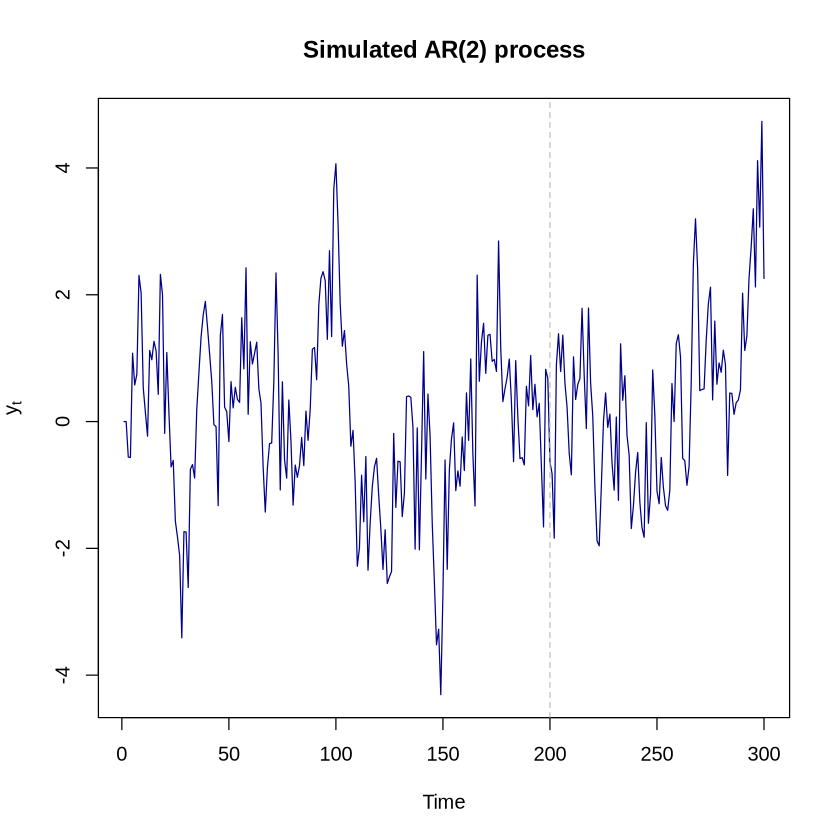

In [1]:
set.seed(123)

T_full  <- 300
T_train <- 200
T_test  <- T_full - T_train

phi1 <- 0.6
phi2 <- 0.25

y_full <- numeric(T_full)
for (t in 3:T_full) {
    y_full[t] <- phi1 * y_full[t - 1] + phi2 * y_full[t - 2] + rnorm(1, sd = 1)
}

y_train <- y_full[1:T_train]
y_test  <- y_full[(T_train + 1):T_full]

plot(y_full, type = "l", col = "darkblue",
     main = "Simulated AR(2) process",
     xlab = "Time", ylab = expression(y[t]))
abline(v = T_train, lty = 2, col = "grey")

---

## Part 2: Fit AR(p) for p = 1, ..., 10 and compute three metrics

For each candidate `p` we compute:

- in-sample **RSS** → from which we derive AIC and BIC,
- out-of-sample **RMSE** with a recursive 1-step forecast on the test set.

### Hints

- A consistent way to compute AIC/BIC across `p` is to drop the first `p_max` residuals so all models use the same window.
- Recursive forecasting: at each step, use the trained model and update the rolling history with the **observed** test value.

In [2]:
orders <- 1:10
p_max  <- max(orders)

lag_results <- lapply(orders, function(p) {

    fit <- ar(y_train, method = "ols", order.max = p, aic = FALSE)

    # recursive 1-step forecast on the test set
    fc     <- numeric(T_test)
    y_roll <- y_train
    for (i in 1:T_test) {
        nr   <- length(y_roll)
        pred <- fit$x.mean
        if (p > 0) {
            for (lag in 1:p) {
                pred <- pred + fit$ar[lag] * (y_roll[nr - lag + 1] - fit$x.mean)
            }
        }
        fc[i]  <- pred
        y_roll <- c(y_roll, y_test[i])
    }

    # in-sample residuals on a common window for fair AIC/BIC
    res_all        <- as.numeric(fit$resid)
    res_consistent <- res_all[(p_max + 1):T_train]
    rss            <- sum(res_consistent^2)
    n              <- length(res_consistent)
    k              <- p + 1            # +1 for intercept

    aic <- n * log(rss / n) + 2 * k
    bic <- n * log(rss / n) + log(n) * k
    rmse_oos <- sqrt(mean((y_test - fc)^2))

    data.frame(p = p, AIC = aic, BIC = bic, RMSE_OOS = rmse_oos)
})

lag_df <- do.call(rbind, lag_results)
print(lag_df, row.names = FALSE)

  p        AIC        BIC  RMSE_OOS
  1  -9.541962 -3.0479135 0.9584131
  2 -19.289988 -9.5489155 0.9525981
  3 -19.679264 -6.6911676 0.9701387
  4 -21.292341 -5.0572202 0.9918409
  5 -20.104979 -0.6228349 0.9845989
  6 -19.116303  3.6128659 0.9921032
  7 -17.210272  8.7659204 0.9892679
  8 -15.458853 13.7643636 0.9869105
  9 -14.120988 18.3492530 0.9790776
 10 -12.282539 23.4347255 0.9769357


---

## Part 3: Visualise the three criteria

We plot AIC and BIC **relative to their minimum** so the curves are directly comparable.

A red shaded band marks the **underfit** region ($p<2$), a blue band the **overfit** region ($p>2$). Interpret the results.

p with minimum OOS RMSE: 2 


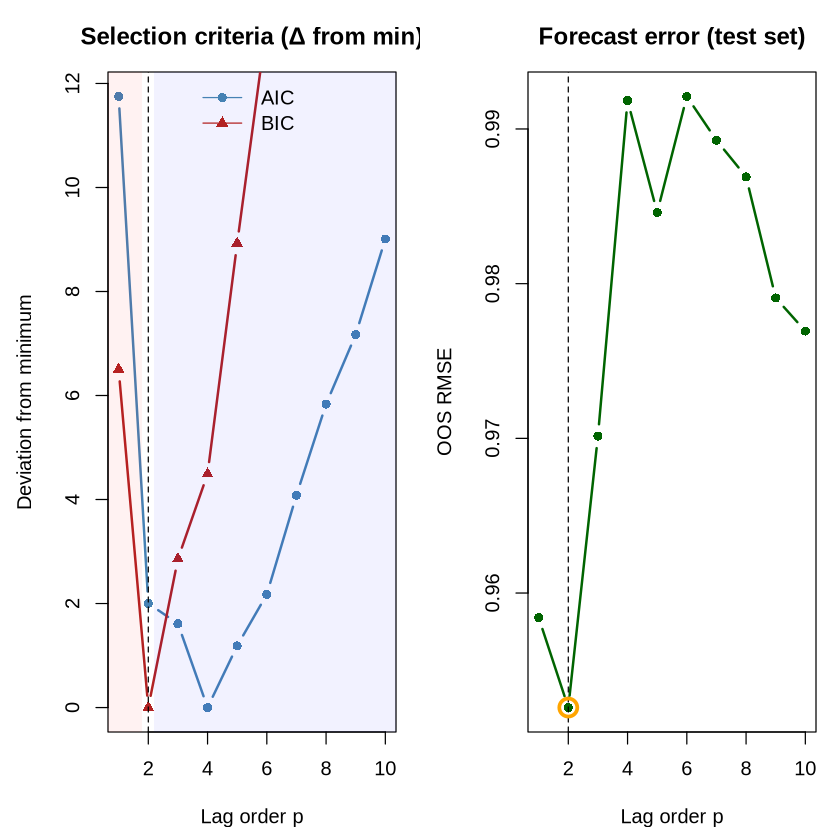

In [3]:
par(mfrow = c(1, 2), mar = c(4.5, 4.5, 3, 1))

# (A) Information criteria
plot(lag_df$p, lag_df$AIC - min(lag_df$AIC),
     type = "b", pch = 16, col = "steelblue", lwd = 2,
     main = "Selection criteria (Δ from min)",
     xlab = "Lag order p", ylab = "Deviation from minimum")
lines(lag_df$p, lag_df$BIC - min(lag_df$BIC),
      type = "b", pch = 17, col = "firebrick", lwd = 2)

abline(v = 2, lty = 2)
text(2.5, max(lag_df$BIC - min(lag_df$BIC)) * 0.8, "True p = 2", pos = 4)

rect(-1, -10, 1.8, 1000, col = rgb(1, 0, 0, 0.05), border = NA)
rect(2.2, -10, 16, 1000, col = rgb(0, 0, 1, 0.05), border = NA)

legend("top", legend = c("AIC", "BIC"),
       col = c("steelblue", "firebrick"),
       pch = c(16, 17), lty = 1, bty = "n")

# (B) Out-of-sample RMSE
plot(lag_df$p, lag_df$RMSE_OOS,
     type = "b", pch = 16, col = "darkgreen", lwd = 2,
     main = "Forecast error (test set)",
     xlab = "Lag order p", ylab = "OOS RMSE")
abline(v = 2, lty = 2)

best_p <- lag_df$p[which.min(lag_df$RMSE_OOS)]
points(best_p, min(lag_df$RMSE_OOS), col = "orange", cex = 2, lwd = 3)

par(mfrow = c(1, 1))
cat("p with minimum OOS RMSE:", best_p, "\n")

### Discussion

- **Why AIC and BIC sometimes disagree.** BIC's $\log n$ penalty grows with sample size, so as $n \to \infty$ BIC consistently picks the *true* model. AIC is asymptotically optimal for *prediction*, not for identification.
- **Why OOS RMSE can disagree with both.** With finite data, the predictive optimum can be at a slightly different $p$ than the truth — especially when extra lags pick up small but real structure that helps prediction.
- **Explanation vs. forecasting.** If you want to *describe* the data-generating process → BIC tends to be more conservative. If you want to *predict* → trust OOS RMSE.

---

## Wrap-up

- Compute AIC, BIC, and OOS RMSE across a grid of lag orders.
- Identify under- and overfitting regions.
- Recognise that the "best" model depends on what you want to do with it.